In [9]:
#===============================================================================
#
# Name: digitise-graph.ipynb
#
# Author: MT
#
# Date: 02/01/2026
#
# Purpose: Extract data points from a graph image using Python 
#
# Steps:
# Step 0: Imports
# Step 1: Helper Functions
# Step 2: Load Image
# Step 3: Crop Image
# Step 4: Process Image to Extract Data
# Step 5: Plot Extracted Data
#
#===============================================================================

In [10]:
#===============================================================================
# Step 0: Imports

# Pandas and NumPy
import numpy as np
import pandas as pd

# Python Imaging Library
from PIL import Image

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
#===============================================================================

In [11]:
#===============================================================================
# Step 1: Helper Functions

#------------------
def rgb_to_hsv_array(arr_rgb_uint8: np.ndarray):
    """Vectorized RGB->HSV. Returns (h,s,v) in [0,1]."""
    rgb = arr_rgb_uint8.astype(np.float32) / 255.0
    r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    maxc = np.max(rgb, axis=2)
    minc = np.min(rgb, axis=2)
    v = maxc
    delt = maxc - minc

    s = np.where(maxc == 0, 0, delt / maxc)

    h = np.zeros_like(maxc)
    mask = delt != 0

    # Avoid warnings on divide-by-zero (masked out anyway)
    rc = np.zeros_like(maxc)
    gc = np.zeros_like(maxc)
    bc = np.zeros_like(maxc)
    rc[mask] = (maxc[mask] - r[mask]) / delt[mask]
    gc[mask] = (maxc[mask] - g[mask]) / delt[mask]
    bc[mask] = (maxc[mask] - b[mask]) / delt[mask]

    idx = mask & (r == maxc)
    h[idx] = (bc - gc)[idx]
    idx = mask & (g == maxc)
    h[idx] = 2.0 + (rc - bc)[idx]
    idx = mask & (b == maxc)
    h[idx] = 4.0 + (gc - rc)[idx]

    h = (h / 6.0) % 1.0
    return h, s, v
#------------------

#------------------
def hue_between(h, low, high):
    """Inclusive hue range, with wrap-around support."""
    if low <= high:
        return (h >= low) & (h <= high)
    return (h >= low) | (h <= high)
#------------------

#------------------
def extract_series_y(mask, plot_mask, x_min, x_max):
    """For each x, take median y of masked pixels."""
    h, w = mask.shape
    ys = np.full(w, np.nan, dtype=float)
    for x in range(x_min, x_max + 1):
        y_idx = np.where(mask[:, x] & plot_mask[:, x])[0]
        if len(y_idx):
            ys[x] = np.median(y_idx)
    return pd.Series(ys[x_min:x_max + 1], index=np.arange(x_min, x_max + 1), dtype=float)
#------------------

#------------------
def sample_monthly(series_by_x, dates, x_min, x_max):
    """Interpolate along x and sample to monthly dates."""
    s = series_by_x.interpolate(limit_direction="both")
    xs = s.index.values.astype(float)
    ys = s.values.astype(float)
    n = len(dates)
    x_pos = x_min + np.linspace(0, 1, n) * (x_max - x_min)
    sampled = np.interp(x_pos, xs, ys)
    return pd.Series(sampled, index=dates)
#------------------
#===============================================================================

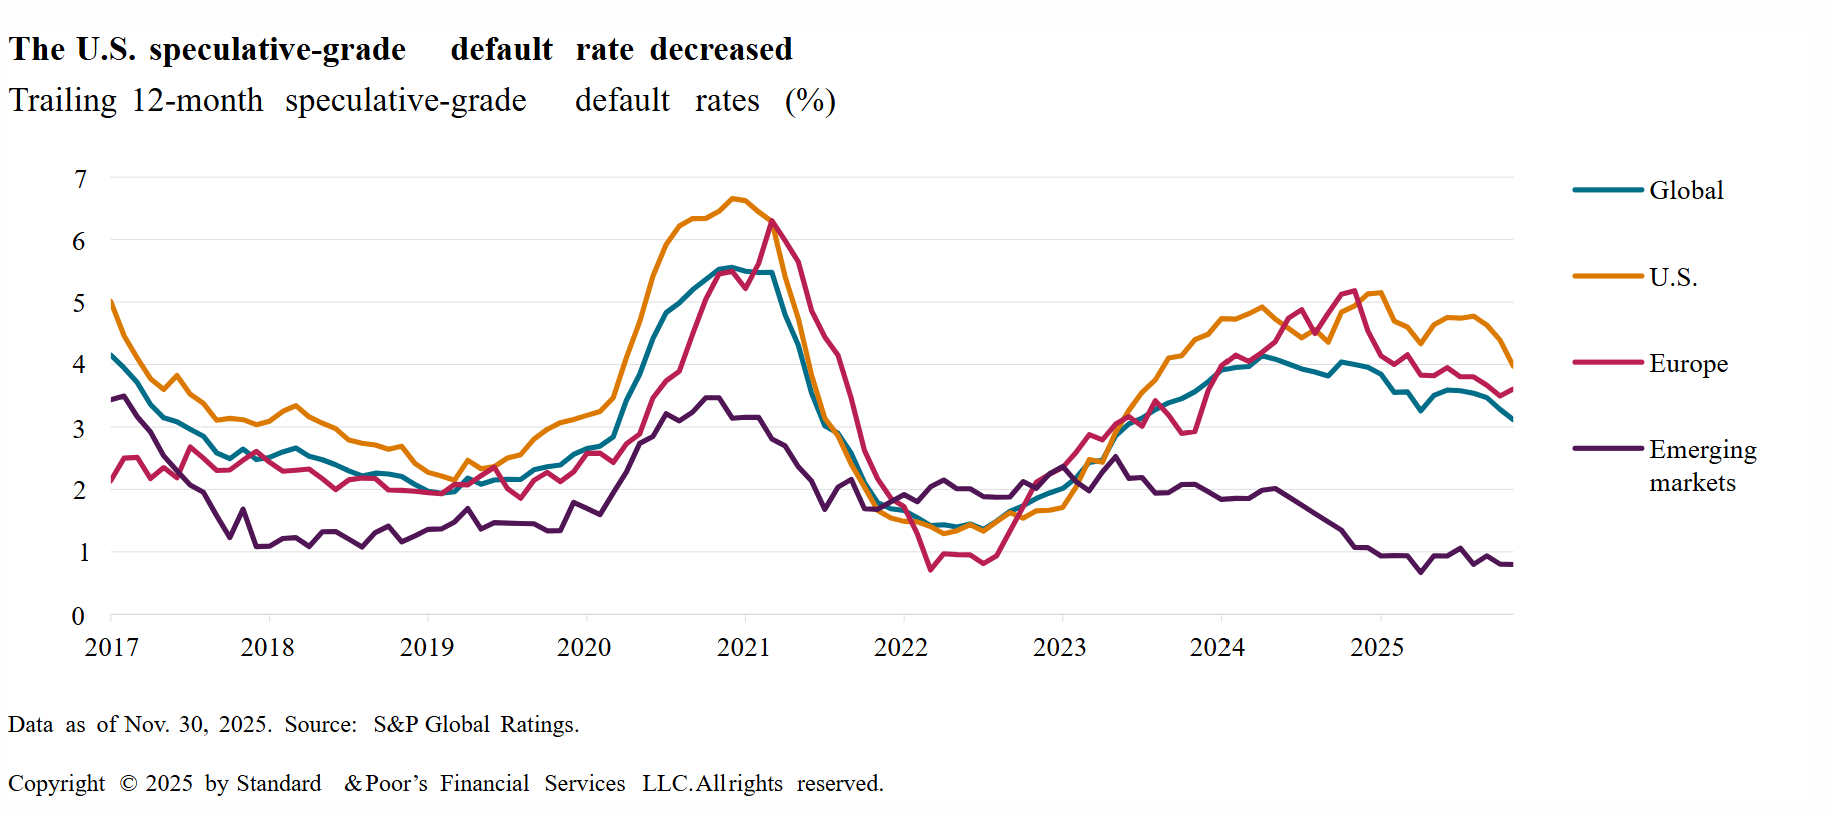

In [12]:
#===============================================================================
# Step 2: Load Image 
png_path = "Input/digitise-graph.png"
img = Image.open(png_path).convert("RGB")
img
#===============================================================================

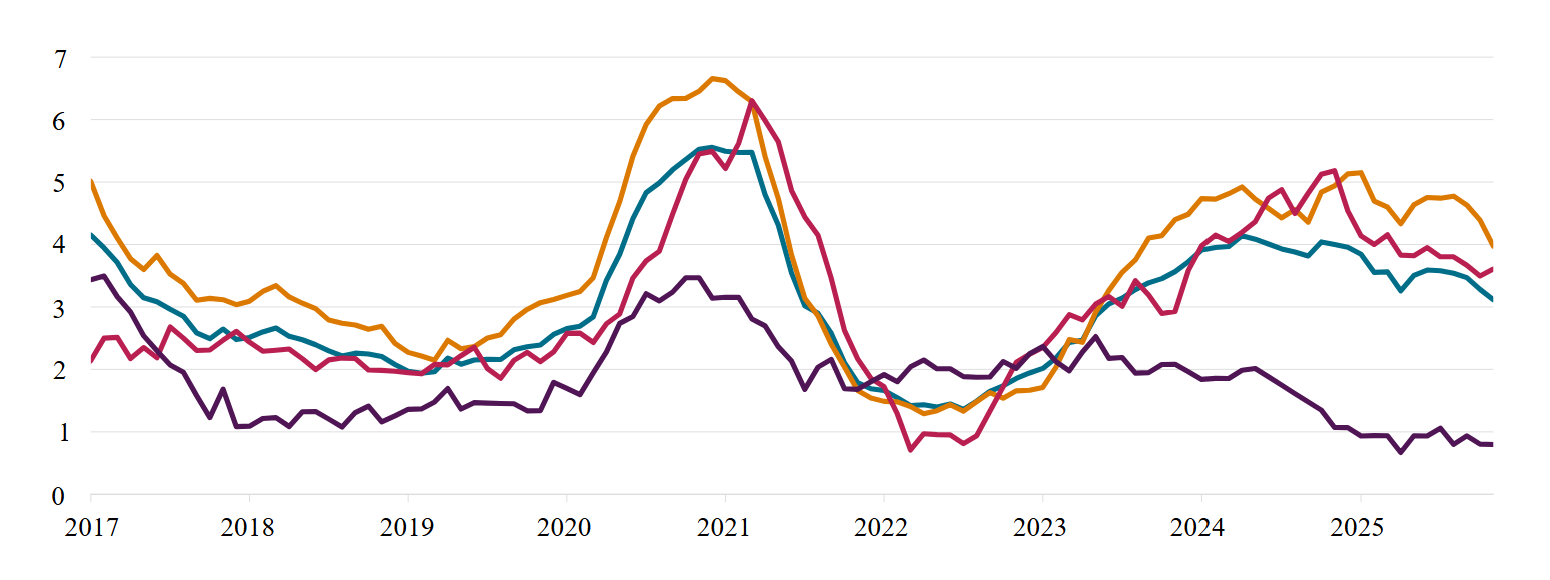

In [13]:
#===============================================================================
# Step 3: Crop Image
crop = img.crop((20, 120, 1570, 700)).convert("RGB")
crop
#===============================================================================

In [14]:
#===============================================================================
# Step 4: Process Image to Extract Data

arr = np.array(crop)
H, W, _ = arr.shape

# --- Detect gridlines to map pixels -> y-axis values (0..7) ---
r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
gray_grid = (np.abs(r - g) < 3) & (np.abs(r - b) < 3) & (r > 215) & (r < 250)
frac = gray_grid.mean(axis=1)
cand = np.where(frac > 0.2)[0]

clusters = []
start = None
for y in cand:
    if start is None:
        start = y
        prev = y
    elif y == prev + 1:
        prev = y
    else:
        clusters.append((start, prev))
        start = y
        prev = y
if start is not None:
    clusters.append((start, prev))

grid_y = np.array([(a + b) / 2 for a, b in clusters])  # 8 horizontal lines expected
grid_y = np.sort(grid_y)  # top->bottom
vals = np.arange(7, -1, -1)  # 7..0

# Fit y_pix = m*val + c
m, c0 = np.polyfit(vals, grid_y, 1)

def ypix_to_value(y_pix):
    return (y_pix - c0) / m  # m is negative

# --- Detect baseline x-range (plot width) ---
grayish = (np.abs(r - g) < 5) & (np.abs(r - b) < 5) & (r > 170) & (r < 240)
scores = [(grayish[y].mean(), y) for y in range(int(H * 0.6), H)]
baseline_y = max(scores)[1]

row = grayish[baseline_y]
xs = np.where(row)[0]
x_min, x_max = int(xs.min()), int(xs.max())

plot_mask = np.zeros((H, W), dtype=bool)
plot_mask[:baseline_y, x_min:x_max + 1] = True

# --- Segment line colors in HSV ---
hue, sat, val = rgb_to_hsv_array(arr)

# Hue bands tuned to this chart’s line colors
mask_global = hue_between(hue, 0.48, 0.62) & (sat > 0.50) & (val > 0.20)  # teal
mask_us     = hue_between(hue, 0.05, 0.15) & (sat > 0.50) & (val > 0.20)  # orange
mask_europe = hue_between(hue, 0.90, 1.00) & (sat > 0.50) & (val > 0.20)  # magenta
mask_em     = hue_between(hue, 0.74, 0.88) & (sat > 0.35) & (val > 0.20)  # purple

# --- Extract y pixel positions by x, then convert to values ---
global_y = extract_series_y(mask_global, plot_mask, x_min, x_max)
us_y     = extract_series_y(mask_us,     plot_mask, x_min, x_max)
europe_y = extract_series_y(mask_europe, plot_mask, x_min, x_max)
em_y     = extract_series_y(mask_em,     plot_mask, x_min, x_max)

global_v = ypix_to_value(global_y)
us_v     = ypix_to_value(us_y)
europe_v = ypix_to_value(europe_y)
em_v     = ypix_to_value(em_y)

# --- Sample to monthly dates (assumes chart is monthly, Jan 2017 .. Nov 2025) ---
dates = pd.date_range("2017-01-01", "2025-11-01", freq="MS")

# --- Create DataFrame and save to CSV ---
df = pd.DataFrame({
    "Global": sample_monthly(global_v, dates, x_min, x_max),
    "U.S.": sample_monthly(us_v, dates, x_min, x_max),
    "Europe": sample_monthly(europe_v, dates, x_min, x_max),
    "Emerging markets": sample_monthly(em_v, dates, x_min, x_max),
})
df.to_csv("digitise-graph.csv", index_label="Date")
print(df.head())
print(df.tail())
#===============================================================================

              Global      U.S.    Europe  Emerging markets
2017-01-01  4.135424  4.959973  2.166111          3.438959
2017-02-01  3.947525  4.488112  2.474090          3.477098
2017-03-01  3.707818  4.111861  2.498559          3.171460
2017-04-01  3.373935  3.790212  2.194809          2.917631
2017-05-01  3.159226  3.607525  2.341322          2.551726
              Global      U.S.    Europe  Emerging markets
2025-07-01  3.582602  4.735824  3.807205          1.044910
2025-08-01  3.535023  4.765504  3.796858          0.810868
2025-09-01  3.462975  4.615291  3.662656          0.925284
2025-10-01  3.274623  4.365237  3.504890          0.800974
2025-11-01  3.126751  4.007338  3.599066          0.797198


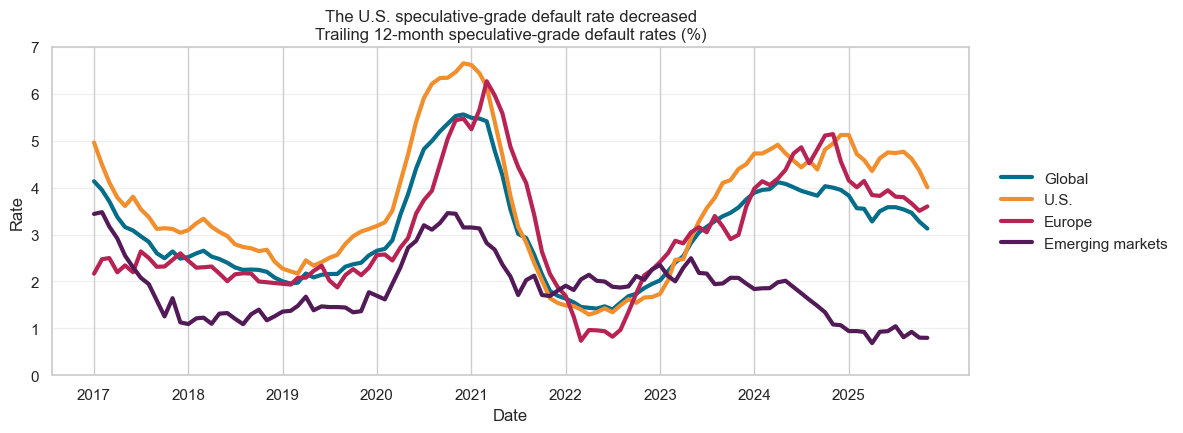

In [17]:
#===============================================================================
# Step 5: Plot Extracted Data

colors = {
    "Global": "#046d8a",
     "U.S.": "#f28e2b",
    "Europe": "#b92353",
    "Emerging markets": "#531a58",
}

# long-form for seaborn
df_long = (
    df.reset_index()
      .rename(columns={"index": "Date"})
      .melt(id_vars="Date", var_name="Region", value_name="Rate")
)

sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 4.5))
sns.lineplot(
    data=df_long,
    x="Date", y="Rate",
    hue="Region",
    palette=colors,
    linewidth=3
)

plt.ylim(0, 7)
plt.grid(axis="y", alpha=0.3)

years = pd.date_range("2017-01-01", "2025-01-01", freq="YS")
plt.xticks(years, [d.year for d in years])

plt.title("The U.S. speculative-grade default rate decreased\nTrailing 12-month speculative-grade default rates (%)")

plt.legend(title=None, loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.savefig("digitised-chart-output.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()
#===============================================================================